# BrailleLens — robust fingertip detector (YOLO26n fine-tune, lighting-robust, says "no fingertip")

Trains a new fingertip model from **`yolo26n.pt`** (COCO-pretrained) that
1. finds the index fingertip on **Braille pages and glasses-camera frames** under dim / side / uneven light, and
2. reports **no fingertip** when there is none (empty page, desk, hand without a visible tip).

**Why a new run:** the 3 Oct combined model never saw the Braille photos — its notebook picked up
`MyDrive/BrailleLens/fingertip_yolo26` (public data only, 306 test images) instead of the combined zip. Even inside the
combined zip the Braille photos are 48 of 12,585 training images (0.4%). Result: 0/12 Braille images and 1/40 glasses
frames, vs 12/12 and 15/40 for the model in the app.

### What this notebook does
| Problem | Technique |
|---|---|
| Braille domain drowned by public data | Domain **oversampling** of the 48 Braille photos (×30 augmented variants) + **pseudo-labelled glasses-video frames** (labels from the current Braille model, confident frames + short-gap interpolation) |
| Lighting | Offline photometric augmentation: directional light ramps, cast shadows, dim light with sensor noise + auto-gain, colour temperature, motion/defocus blur, glasses-camera softening, JPEG; Ultralytics HSV jitter on top. *Glare* is held out of training to measure robustness to an unseen effect |
| Small / far fingertips (glasses) | **Zoom-out composites** (photo shrunk and pasted on a page/desk background), mosaic, scale jitter |
| Tip at the frame edge, close-ups | Edge crops that cut through the tip (clipped boxes), tight crops |
| Saying "no fingertip" | **Background images with empty labels** (~25% of training images, counting the public set's own backgrounds): Gold Braille pages, glasses frames with no hand, **tip-free crops** of the Braille photos (finger body / hand / page without the tip = hard negatives), COCO scenes without people, your `negatives_extra/`; **confidence threshold chosen on validation data that includes negatives** |
| Honest numbers | Held-out Braille test photos (+ the same under 7 lighting corruptions), public test, **held-out glasses-video segment** (different time range from training), several negative sets; current vs combined vs new; app-faithful ONNX re-check |

### Drive layout (folder `MyDrive/BrailleLens_Fingertip_Domain/`)
| File | From |
|---|---|
| `fingertip_robust_bundle.zip` | PC: `finger_cell_track\.venv\Scripts\python.exe finger_cell_track/fingertip_robust/pack_for_colab.py` → `colab_upload/` |
| `fingertip_combined_yolo26.zip` | already on Drive (public TI1K + Roboflow). Fallback: the unzipped folder `MyDrive/BrailleLens/fingertip_yolo26/` |

Outputs go to `MyDrive/BrailleLens_Fingertip_Domain/fingertip_robust_outputs/`.
**Runtime → T4 GPU → Run all** (~2.5–3 h). If Colab disconnects, just **Run all** again: the dataset is rebuilt
identically (seeded) and training **resumes** from the last checkpoint on Drive.

In [3]:
!pip -q install -U ultralytics onnx onnxruntime onnxslim opencv-python-headless

## 1) Setup and configuration

In [4]:
import json, math, random, shutil, sys, time, zipfile
from pathlib import Path

import cv2
import numpy as np
import torch

assert torch.cuda.is_available(), "Runtime -> Change runtime type -> T4 GPU"
from google.colab import drive

try:
    drive.mount("/content/drive")
    DRIVE = Path("/content/drive/MyDrive/BrailleLens_Fingertip_Domain")
except Exception as e:  # "credential propagation was unsuccessful": upload the zips to /content/ via the Files panel
    print(f"Drive mount failed ({e}); using /content (download outputs before the session ends)")
    DRIVE = Path("/content")
DRIVE.mkdir(parents=True, exist_ok=True)

BUNDLE = next((p for p in (DRIVE / "fingertip_robust_bundle.zip", Path("/content/fingertip_robust_bundle.zip")) if p.exists()), None)
assert BUNDLE, f"Upload fingertip_robust_bundle.zip to {DRIVE}"
PUBLIC_CANDIDATES = [DRIVE / "fingertip_combined_yolo26.zip", Path("/content/fingertip_combined_yolo26.zip"),
                     Path("/content/drive/MyDrive/BrailleLens/fingertip_yolo26"), DRIVE / "fingertip_yolo26.zip"]
PUBLIC_SRC = next((p for p in PUBLIC_CANDIDATES if p.exists()), None)
assert PUBLIC_SRC, f"Public fingertip data not found in any of {PUBLIC_CANDIDATES}"
OUT = DRIVE / "fingertip_robust_outputs"; OUT.mkdir(parents=True, exist_ok=True)
WORK = Path("/content/ftr"); WORK.mkdir(exist_ok=True)

PUBLIC_TRAIN_MAX = 8000   # random subset of the ~12.5k public training images (keeps an epoch ~2.5 min on a T4)
BR_VARIANTS = 30          # augmented copies per Braille training photo
GL_VARIANTS = 2           # augmented copies per pseudo-labelled glasses frame
GOLD_VARIANTS = 15        # augmented copies per Gold page (negatives)
TIPFREE_PER_IMG = 6       # tip-free crops per Braille training photo (negatives)
COCO_VARIANTS = 3
HELDOUT_FAMILIES = ["glare"]
EPOCHS, IMGSZ, BATCH, PATIENCE = 60, 640, 32, 20
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if not (WORK / "bundle" / "bundle_meta.json").exists():
    with zipfile.ZipFile(BUNDLE) as z:
        z.extractall(WORK / "bundle")
B = WORK / "bundle"
BMETA = json.loads((B / "bundle_meta.json").read_text())
print("bundle:", BUNDLE, BMETA["counts"])
print("public data:", PUBLIC_SRC)

Mounted at /content/drive
bundle: /content/drive/MyDrive/BrailleLens_Fingertip_Domain/fingertip_robust_bundle.zip {'braille_train': 48, 'braille_val': 6, 'braille_test': 6, 'gold_train': 16, 'gold_val': 2, 'gold_test': 4, 'train_pos': 136, 'eval_pos': 131, 'train_neg': 95, 'eval_neg': 68, 'ambiguous': 25}
public data: /content/drive/MyDrive/BrailleLens_Fingertip_Domain/fingertip_combined_yolo26.zip


## 2) Public fingertip data (TI1K + Roboflow) from Drive
Copied to local disk first (training straight from Drive is ~10× slower). The Braille photos inside the public zip
(`braille_*`) are dropped here — they come from the bundle instead, with their own oversampling and fixed split.

In [5]:
PUB = WORK / "public"
def find_root(base):
    for y in sorted(base.rglob("data.yaml")):
        if (y.parent / "images" / "train").is_dir():
            return y.parent
    return None

if find_root(PUB) is None:
    PUB.mkdir(exist_ok=True)
    t0 = time.time()
    if PUBLIC_SRC.suffix == ".zip":
        with zipfile.ZipFile(PUBLIC_SRC) as z:
            z.extractall(PUB)
    else:
        shutil.copytree(PUBLIC_SRC, PUB / PUBLIC_SRC.name, dirs_exist_ok=True)
    print(f"copied public data in {time.time() - t0:.0f}s")
PUB_ROOT = find_root(PUB)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def public_split(split):
    items = []
    for ip in sorted((PUB_ROOT / "images" / split).iterdir()):
        if ip.suffix.lower() not in IMG_EXT or ip.name.startswith("braille_"):
            continue
        items.append((ip, PUB_ROOT / "labels" / split / f"{ip.stem}.txt"))
    return items

PUBLIC = {s: public_split(s) for s in ("train", "val", "test")}
rng = random.Random(SEED)
if len(PUBLIC["train"]) > PUBLIC_TRAIN_MAX:
    PUBLIC["train"] = rng.sample(PUBLIC["train"], PUBLIC_TRAIN_MAX)
def n_bg(items): return sum(1 for _, lp in items if not lp.exists() or not lp.read_text().strip())
for s, v in PUBLIC.items():
    print(f"public {s:5s}: {len(v)} images ({n_bg(v)} without a fingertip)")

copied public data in 24s
public train: 8000 images (2259 without a fingertip)
public val  : 757 images (203 without a fingertip)
public test : 306 images (85 without a fingertip)


## 3) Augmentation library
Photometric functions take a uint8 BGR image and return uint8. Geometric helpers work on pixel boxes `[x0, y0, x1, y1]`.

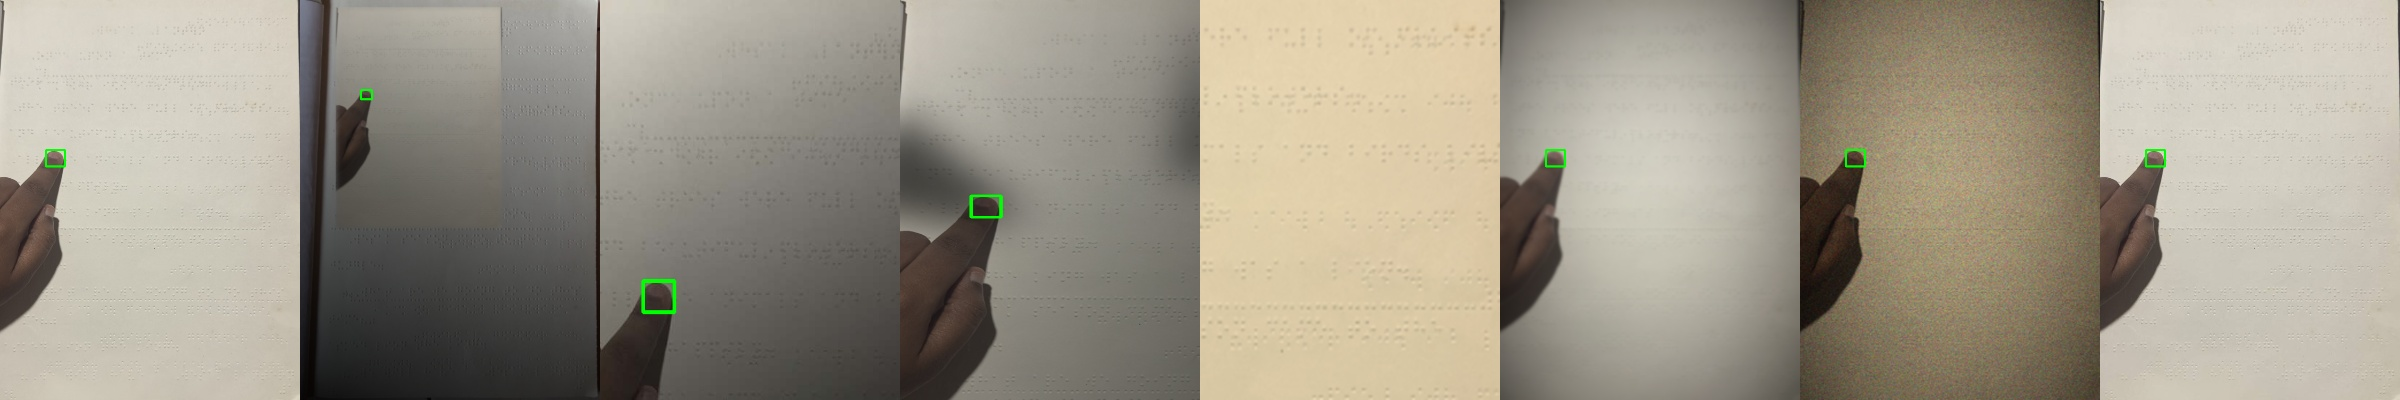

original | zoom-out | close-up | tip at edge | tip-free crop (negative) | 3 random lighting variants


In [6]:
def _f(x): return x.astype(np.float32)
def _u8(x): return np.clip(x, 0, 255).astype(np.uint8)
def _gain(img, g): return _u8(_f(img) * g[..., None])

def directional(img, rng, strength=None):
    h, w = img.shape[:2]
    th = rng.uniform(0, 2 * np.pi)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    proj = ((xx - w / 2) * np.cos(th) + (yy - h / 2) * np.sin(th)) / (0.5 * np.hypot(w, h))
    lo = 1 - (rng.uniform(0.3, 0.85) if strength is None else strength)
    return _gain(img, (lo + (1 - lo) * np.clip((proj + 1) / 2, 0, 1)) ** rng.uniform(0.8, 1.6))

def vignette(img, rng, strength=None):
    h, w = img.shape[:2]
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    r = np.hypot((xx - w / 2) / (w / 2), (yy - h / 2) / (h / 2)) / np.sqrt(2)
    return _gain(img, 1 - (rng.uniform(0.2, 0.6) if strength is None else strength) * r ** 2)

def cast_shadow(img, rng, darkness=None):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), np.float32)
    for _ in range(rng.integers(1, 3)):
        cx, cy, rad = rng.uniform(0, w), rng.uniform(0, h), rng.uniform(0.15, 0.5) * max(h, w)
        ang = np.sort(rng.uniform(0, 2 * np.pi, rng.integers(5, 9)))
        rr = rad * rng.uniform(0.5, 1.2, len(ang))
        cv2.fillPoly(mask, [np.stack([cx + rr * np.cos(ang), cy + rr * np.sin(ang)], 1).astype(np.int32)], 1.0)
    mask = cv2.GaussianBlur(mask, (0, 0), max(h, w) * rng.uniform(0.02, 0.08))
    return _gain(img, 1 - (rng.uniform(0.3, 0.65) if darkness is None else darkness) * np.clip(mask, 0, 1))

def color_temp(img, rng, warm=None):
    warm = rng.uniform(-1, 1) if warm is None else warm
    return _u8(_f(img) * np.array([1 - 0.25 * warm, 1.0, 1 + 0.15 * warm], np.float32))

def low_light(img, rng, exposure=None):
    """Dark room: few photons -> shot + read noise -> camera auto-gain -> optional denoise smear."""
    k = rng.uniform(0.1, 0.5) if exposure is None else exposure
    x = _f(img) / 255.0 * k
    a, b = rng.uniform(0.004, 0.014), rng.uniform(1e-5, 3e-4)
    x = x + rng.standard_normal(x.shape).astype(np.float32) * np.sqrt(np.maximum(x * a + b, 1e-8))
    out = _u8(np.clip(x / k * rng.uniform(0.5, 0.95), 0, 1) ** rng.uniform(0.85, 1.3) * 255)
    return cv2.GaussianBlur(out, (0, 0), rng.uniform(0.5, 1.2)) if rng.random() < 0.5 else out

def blur(img, rng, amount=None):
    s = max(img.shape[:2]) / 640
    if rng.random() < 0.6:  # motion blur: the finger moves while reading
        k = int(round((rng.uniform(3, 11) if amount is None else amount * 3) * s)) | 1
        kern = np.zeros((k, k), np.float32); kern[k // 2, :] = 1.0 / k
        kern = cv2.warpAffine(kern, cv2.getRotationMatrix2D((k / 2 - 0.5, k / 2 - 0.5), rng.uniform(0, 180), 1.0), (k, k))
        return cv2.filter2D(img, -1, kern / max(kern.sum(), 1e-6))
    return cv2.GaussianBlur(img, (0, 0), (rng.uniform(0.6, 2.0) if amount is None else amount) * s)

def glasses_soft(img, rng, factor=0.39):
    h, w = img.shape[:2]
    small = cv2.resize(img, (max(2, int(w * factor)), max(2, int(h * factor))), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)

def jpeg(img, rng, q=None):
    ok, buf = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, int(rng.uniform(25, 75) if q is None else q)])
    return cv2.imdecode(buf, cv2.IMREAD_COLOR)

def glare(img, rng, strength=None):
    h, w = img.shape[:2]
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    cx, cy, rad = rng.uniform(0.2, 0.8) * w, rng.uniform(0.2, 0.8) * h, rng.uniform(0.1, 0.3) * max(h, w)
    blob = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * rad ** 2))
    return _u8(_f(img) + (blob * (rng.uniform(60, 140) if strength is None else strength))[..., None])

def grayscale(img, rng):
    return cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)

def random_lighting(img, rng, exclude=HELDOUT_FAMILIES):
    ops = [("directional", 0.6, directional), ("vignette", 0.3, vignette), ("shadow", 0.4, cast_shadow),
           ("color_temp", 0.4, color_temp), ("low_light", 0.4, low_light), ("blur", 0.4, blur),
           ("glasses", 0.15, glasses_soft), ("grayscale", 0.05, grayscale), ("jpeg", 0.4, jpeg), ("glare", 0.2, glare)]
    for name, p, fn in ops:
        if name not in exclude and rng.random() < p:
            img = fn(img, rng)
    return img

def corrupt(img, family, sev, seed):
    """Fixed-severity corruption for the benchmark (identical for every model)."""
    rng = np.random.default_rng(seed); s = sev - 1
    if family == "dark":        return low_light(img, rng, exposure=[0.4, 0.22, 0.1][s])
    if family == "side_light":  return directional(img, rng, strength=[0.5, 0.7, 0.85][s])
    if family == "shadow":      return cast_shadow(img, rng, darkness=[0.35, 0.5, 0.65][s])
    if family == "blur":        return blur(img, rng, amount=[1.0, 2.0, 3.0][s])
    if family == "glasses":     return glasses_soft(img, rng, factor=[0.5, 0.39, 0.3][s])
    if family == "color_temp":  return color_temp(img, rng, warm=[0.5, -0.8, 1.0][s])
    if family == "glare":       return glare(img, rng, strength=[70, 110, 150][s])
    raise ValueError(family)
FAMILIES = ["dark", "side_light", "shadow", "blur", "glasses", "color_temp", "glare"]

# ---- geometry ----
def clip_boxes(boxes, w, h, min_vis=0.4, orig=None):
    """Clip to the image; drop boxes with less than min_vis of their area left."""
    if len(boxes) == 0:
        return boxes.reshape(0, 4)
    b = boxes.copy(); b[:, [0, 2]] = b[:, [0, 2]].clip(0, w); b[:, [1, 3]] = b[:, [1, 3]].clip(0, h)
    area = lambda z: (z[:, 2] - z[:, 0]).clip(0) * (z[:, 3] - z[:, 1]).clip(0)
    keep = area(b) >= min_vis * np.maximum(area(boxes if orig is None else orig), 1e-6)
    return b[keep]

def crop(img, boxes, x0, y0, x1, y1, min_vis=0.4):
    x0, y0, x1, y1 = map(int, (x0, y0, x1, y1))
    shifted = boxes - np.array([x0, y0, x0, y0], np.float32)
    return img[y0:y1, x0:x1].copy(), clip_boxes(shifted, x1 - x0, y1 - y0, min_vis)

def tight_crop(img, boxes, rng):
    """Close-up: random crop 40-80% of the image that keeps the tip inside."""
    h, w = img.shape[:2]; bx = boxes[0]
    cw, ch = int(w * rng.uniform(0.4, 0.8)), int(h * rng.uniform(0.4, 0.8))
    x_lo, x_hi = max(0, bx[2] - cw), max(0, min(bx[0], w - cw))
    y_lo, y_hi = max(0, bx[3] - ch), max(0, min(bx[1], h - ch))
    x0 = rng.uniform(x_lo, x_hi) if x_hi > x_lo else min(x_lo, w - cw)
    y0 = rng.uniform(y_lo, y_hi) if y_hi > y_lo else min(y_lo, h - ch)
    return crop(img, boxes, x0, y0, x0 + cw, y0 + ch)

def edge_crop(img, boxes, rng):
    """Tip partly out of frame: a crop edge cuts through the tip box (40-75% stays visible)."""
    h, w = img.shape[:2]; bx = boxes[0]; bw, bh = bx[2] - bx[0], bx[3] - bx[1]
    side = rng.integers(4); keep = rng.uniform(0.4, 0.75)
    cw, ch = int(w * rng.uniform(0.5, 0.8)), int(h * rng.uniform(0.5, 0.8))
    if side == 0:   x0 = bx[0] + (1 - keep) * bw; y0 = np.clip(bx[1] - rng.uniform(0, ch - bh), 0, h - ch)
    elif side == 1: x0 = bx[2] - keep * bw - cw; y0 = np.clip(bx[1] - rng.uniform(0, ch - bh), 0, h - ch)
    elif side == 2: y0 = bx[1] + (1 - keep) * bh; x0 = np.clip(bx[0] - rng.uniform(0, cw - bw), 0, w - cw)
    else:           y0 = bx[3] - keep * bh - ch; x0 = np.clip(bx[0] - rng.uniform(0, cw - bw), 0, w - cw)
    x0, y0 = float(np.clip(x0, 0, w - cw)), float(np.clip(y0, 0, h - ch))
    return crop(img, boxes, x0, y0, x0 + cw, y0 + ch, min_vis=0.35)

def zoom_out(img, boxes, bg, rng):
    """Small, far fingertip (glasses view): shrink the photo to 30-70% and paste it on a page/desk background."""
    h, w = img.shape[:2]
    bg = cv2.resize(bg, (w, h))
    s = rng.uniform(0.3, 0.7); nw, nh = int(w * s), int(h * s)
    x0, y0 = int(rng.uniform(0, w - nw)), int(rng.uniform(0, h - nh))
    small = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    out = bg.copy(); out[y0:y0 + nh, x0:x0 + nw] = small
    feather = np.zeros((h, w), np.float32); feather[y0:y0 + nh, x0:x0 + nw] = 1
    feather = cv2.GaussianBlur(feather, (0, 0), max(2, 0.01 * w))[..., None]
    out = _u8(feather * _f(out) + (1 - feather) * _f(bg))
    return out, boxes * s + np.array([x0, y0, x0, y0], np.float32)

def tip_free_crop(img, boxes, rng, tries=60):
    """Hard negative: a crop that does not contain the tip (finger body, hand, page). Half are taken just below the tip."""
    h, w = img.shape[:2]; bx = boxes[0]; bw, bh = bx[2] - bx[0], bx[3] - bx[1]
    guard = np.array([bx[0] - bw, bx[1] - bh, bx[2] + bw, bx[3] + bh])
    for _ in range(tries):
        cw, ch = int(w * rng.uniform(0.3, 0.6)), int(h * rng.uniform(0.3, 0.6))
        if rng.random() < 0.5:
            lo, hi = max(0, bx[0] - cw / 2), min(w - cw, bx[0])
            x0 = rng.uniform(lo, hi) if hi > lo else lo
            y0 = guard[3] + rng.uniform(0, 0.1 * h)
        else:
            x0, y0 = rng.uniform(0, w - cw), rng.uniform(0, h - ch)
        x0, y0 = float(np.clip(x0, 0, w - cw)), float(y0)
        if y0 + ch > h:
            continue
        if x0 > guard[2] or x0 + cw < guard[0] or y0 > guard[3] or y0 + ch < guard[1]:
            return img[int(y0):int(y0 + ch), int(x0):int(x0 + cw)].copy()
    return None

def resize_long(img, boxes, long_side=1280):
    h, w = img.shape[:2]; s = long_side / max(h, w)
    if s >= 1:
        return img, boxes
    return cv2.resize(img, (round(w * s), round(h * s)), interpolation=cv2.INTER_AREA), boxes * s

def read_yolo(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]; boxes = []
    if lbl_path is not None and Path(lbl_path).exists():
        for line in Path(lbl_path).read_text().split("\n"):
            p = line.split()
            if len(p) >= 5:
                cx, cy, bw, bh = map(float, p[1:5])
                boxes.append([(cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h])
    return img, np.array(boxes, np.float32).reshape(-1, 4)

# preview
rng = np.random.default_rng(0)
br_train = sorted((B / "braille" / "images" / "train").glob("*.jpg"))
demo, demo_b = read_yolo(br_train[0], B / "braille" / "labels" / "train" / f"{br_train[0].stem}.txt")
demo, demo_b = resize_long(demo, demo_b, 960)
bg_demo = cv2.imread(str(sorted((B / "gold_pages" / "train").glob("*.jpg"))[0]))
tiles = []
for k in range(8):
    im, bx = demo.copy(), demo_b.copy()
    if k == 1: im, bx = zoom_out(im, bx, bg_demo, rng)
    if k == 2: im, bx = tight_crop(im, bx, rng)
    if k == 3: im, bx = edge_crop(im, bx, rng)
    if k == 4:
        im, bx = tip_free_crop(im, bx, rng), np.zeros((0, 4))
    if k > 0: im = random_lighting(im, rng)
    for b in bx:
        cv2.rectangle(im, tuple(map(int, b[:2])), tuple(map(int, b[2:])), (0, 255, 0), 3)
    tiles.append(cv2.resize(im, (300, 400)))
cv2.imwrite(str(OUT / "augmentation_preview.jpg"), np.hstack(tiles))
from IPython.display import Image as _Img, display
display(_Img(str(OUT / "augmentation_preview.jpg"), width=1400))
print("original | zoom-out | close-up | tip at edge | tip-free crop (negative) | 3 random lighting variants")

## 4) Negative images (no fingertip)

In [7]:
def imgs(folder):
    return sorted(p for p in Path(folder).glob("*") if p.suffix.lower() in IMG_EXT)

coco_dir = WORK / "coco128"
if not coco_dir.exists():
    import urllib.request
    urllib.request.urlretrieve("https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip", str(WORK / "coco128.zip"))
    with zipfile.ZipFile(WORK / "coco128.zip") as z:
        z.extractall(WORK)
def has_person(p):
    lp = coco_dir / "labels" / "train2017" / f"{p.stem}.txt"
    return lp.exists() and any(l.split()[0] == "0" for l in lp.read_text().split("\n") if l.strip())
coco = [p for p in imgs(coco_dir / "images" / "train2017") if not has_person(p)]   # people => hands => maybe fingertips
random.Random(SEED).shuffle(coco)
n = len(coco)
COCO = {"train": coco[: int(0.7 * n)], "val": coco[int(0.7 * n): int(0.85 * n)], "test": coco[int(0.85 * n):]}
extra = imgs(B / "negatives_extra")
EXTRA = {"train": extra[: len(extra) // 2], "test": extra[len(extra) // 2:]}
print({k: len(v) for k, v in COCO.items()}, "COCO images without people;", len(extra), "extra negatives")

{'train': 46, 'val': 10, 'test': 11} COCO images without people; 0 extra negatives


## 5) Build the training / validation dataset

In [8]:
DET = WORK / "det"
if DET.exists():
    shutil.rmtree(DET)

def write(img, boxes, split, stem):
    (DET / split / "images").mkdir(parents=True, exist_ok=True); (DET / split / "labels").mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(DET / split / "images" / f"{stem}.jpg"), img, [cv2.IMWRITE_JPEG_QUALITY, 92])
    h, w = img.shape[:2]
    lines = [f"0 {(b[0] + b[2]) / 2 / w:.6f} {(b[1] + b[3]) / 2 / h:.6f} {(b[2] - b[0]) / w:.6f} {(b[3] - b[1]) / h:.6f}"
             for b in clip_boxes(np.asarray(boxes, np.float32).reshape(-1, 4), w, h, 0.0) if b[2] - b[0] >= 1 and b[3] - b[1] >= 1]
    (DET / split / "labels" / f"{stem}.txt").write_text("\n".join(lines) + ("\n" if lines else ""))

def link_public(items, split):
    (DET / split / "images").mkdir(parents=True, exist_ok=True); (DET / split / "labels").mkdir(parents=True, exist_ok=True)
    for ip, lp in items:
        dst = DET / split / "images" / f"pub_{ip.stem}{ip.suffix.lower()}"
        dst.symlink_to(ip)
        (DET / split / "labels" / f"pub_{ip.stem}.txt").write_text(lp.read_text() if lp.exists() else "")

backgrounds = [cv2.imread(str(p)) for p in imgs(B / "gold_pages" / "train") + imgs(B / "glasses" / "train_neg" / "images")[::3]]
rng = np.random.default_rng(SEED)
stats = {}
def count(k, n=1): stats[k] = stats.get(k, 0) + n

def braille_items(split):
    out = []
    for ip in imgs(B / "braille" / "images" / split):
        img, boxes = read_yolo(ip, B / "braille" / "labels" / split / f"{ip.stem}.txt")
        out.append((ip.stem, *resize_long(img, boxes, 1280)))
    return out
BR = {s: braille_items(s) for s in ("train", "val", "test")}

def braille_variant(img, boxes, rng):
    r = rng.random()
    if r < 0.2:   img, boxes = zoom_out(img, boxes, backgrounds[rng.integers(len(backgrounds))], rng)
    elif r < 0.35: img, boxes = tight_crop(img, boxes, rng)
    elif r < 0.5:  img, boxes = edge_crop(img, boxes, rng)
    return random_lighting(img, rng), boxes

# --- train ---
link_public(PUBLIC["train"], "train"); count("public", len(PUBLIC["train"]))
for stem, img, boxes in BR["train"]:
    write(img, boxes, "train", f"br_{stem}"); count("braille")
    for k in range(BR_VARIANTS):
        write(*braille_variant(img, boxes, rng), "train", f"br_{stem}_a{k}"); count("braille")
    for k in range(TIPFREE_PER_IMG):
        neg = tip_free_crop(img, boxes, rng)
        if neg is not None:
            write(random_lighting(neg, rng), [], "train", f"neg_tipfree_{stem}_{k}"); count("neg_tipfree")
for ip in imgs(B / "glasses" / "train_pos" / "images"):
    img, boxes = read_yolo(ip, B / "glasses" / "train_pos" / "labels" / f"{ip.stem}.txt")
    write(img, boxes, "train", f"gl_{ip.stem}"); count("glasses_pos")
    for k in range(GL_VARIANTS):
        im, bx = (tight_crop(img, boxes, rng) if rng.random() < 0.3 else (img, boxes))
        write(random_lighting(im, rng), bx, "train", f"gl_{ip.stem}_a{k}"); count("glasses_pos")
for ip in imgs(B / "gold_pages" / "train"):
    img = cv2.imread(str(ip))
    write(img, [], "train", f"neg_gold_{ip.stem}"); count("neg_gold")
    for k in range(GOLD_VARIANTS):
        im = img
        if rng.random() < 0.5:
            h, w = im.shape[:2]; cw, ch = int(w * rng.uniform(0.4, 0.9)), int(h * rng.uniform(0.4, 0.9))
            x0, y0 = int(rng.uniform(0, w - cw)), int(rng.uniform(0, h - ch)); im = im[y0:y0 + ch, x0:x0 + cw]
        write(random_lighting(im.copy(), rng), [], "train", f"neg_gold_{ip.stem}_a{k}"); count("neg_gold")
for ip in imgs(B / "glasses" / "train_neg" / "images"):
    img = cv2.imread(str(ip))
    write(img, [], "train", f"neg_gl_{ip.stem}"); count("neg_glasses")
    write(random_lighting(img, rng), [], "train", f"neg_gl_{ip.stem}_a"); count("neg_glasses")
for ip in COCO["train"] + EXTRA["train"]:
    img = cv2.imread(str(ip))
    if img is None: continue
    write(img, [], "train", f"neg_coco_{ip.stem}"); count("neg_coco")
    for k in range(COCO_VARIANTS - 1):
        write(random_lighting(img, rng), [], "train", f"neg_coco_{ip.stem}_a{k}"); count("neg_coco")

# --- val: public val + Braille val (original + 5 seeded lighting variants) + negatives ---
link_public(PUBLIC["val"], "val")
VAL_BR, VAL_NEG = [], []
for stem, img, boxes in BR["val"]:
    VAL_BR.append((img, boxes)); write(img, boxes, "val", f"br_{stem}")
    for k in range(5):
        im, bx = braille_variant(img, boxes, np.random.default_rng(100 + k))
        VAL_BR.append((im, bx)); write(im, bx, "val", f"br_{stem}_a{k}")
    for k in range(4):
        neg = tip_free_crop(img, boxes, np.random.default_rng(200 + k))
        if neg is not None:
            VAL_NEG.append(neg); write(neg, [], "val", f"neg_tipfree_{stem}_{k}")
for ip in imgs(B / "gold_pages" / "val"):
    img = cv2.imread(str(ip))
    for k in range(4):
        im = img if k == 0 else random_lighting(img, np.random.default_rng(300 + k))
        VAL_NEG.append(im); write(im, [], "val", f"neg_gold_{ip.stem}_{k}")
for ip in COCO["val"]:
    img = cv2.imread(str(ip)); VAL_NEG.append(img); write(img, [], "val", f"neg_coco_{ip.stem}")

(DET / "data.yaml").write_text(f"path: {DET}\ntrain: train/images\nval: val/images\nnc: 1\nnames:\n  0: fingertip\n")
n_train = len(list((DET / "train" / "images").iterdir()))
n_neg = sum(v for k, v in stats.items() if k.startswith("neg")) + n_bg(PUBLIC["train"])
print("train images by source:", stats)
print(f"train total {n_train}; without a fingertip: {n_neg} ({n_neg / n_train:.0%}); Braille-domain positives: "
      f"{stats['braille'] + stats['glasses_pos']} ({(stats['braille'] + stats['glasses_pos']) / n_train:.0%})")
print(f"val: {len(PUBLIC['val'])} public + {len(VAL_BR)} Braille + {len(VAL_NEG)} negatives")

train images by source: {'public': 8000, 'braille': 1488, 'neg_tipfree': 288, 'glasses_pos': 408, 'neg_gold': 256, 'neg_glasses': 190, 'neg_coco': 138}
train total 10768; without a fingertip: 3131 (29%); Braille-domain positives: 1896 (18%)
val: 757 public + 36 Braille + 42 negatives


## 6) Train — fine-tune `yolo26n.pt` (resumes automatically after a disconnect)

In [9]:
from ultralytics import YOLO
RUNS = OUT / "runs"
LAST, BEST = RUNS / "robust" / "weights" / "last.pt", RUNS / "robust" / "weights" / "best.pt"

def train_finished():
    if not LAST.exists():
        return False
    ck = torch.load(LAST, map_location="cpu", weights_only=False)
    return ck.get("epoch", -1) == -1  # Ultralytics sets epoch=-1 in the final checkpoint

if train_finished():
    print("training already finished:", BEST)
elif LAST.exists():
    YOLO(str(LAST)).train(resume=True)
else:
    YOLO("yolo26n.pt").train(
        data=str(DET / "data.yaml"), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, device=0, workers=4, seed=SEED,
        patience=PATIENCE, cos_lr=True, close_mosaic=10, save_period=5, cache=False,
        hsv_h=0.02, hsv_s=0.6, hsv_v=0.5, degrees=15.0, translate=0.15, scale=0.5, shear=2.0, perspective=0.0005,
        fliplr=0.5, flipud=0.0, mosaic=0.8, mixup=0.05, erasing=0.3,
        project=str(RUNS), name="robust", exist_ok=True)
assert BEST.exists(), BEST
NEW_PT = OUT / "yolo26n_fingertip_robust_best.pt"
shutil.copy2(BEST, NEW_PT)
print("saved", NEW_PT)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/ftr/det/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fre

## 7) Evaluate: current app model vs 3 Oct combined vs new
Mirrors the app (`FingertipOnnxService`): take the **single highest-confidence box**; if it is below the threshold the
answer is **"no fingertip"**.
- **found**: a box above the threshold on an image that has a fingertip.
- **hit**: the box centre lies within one box width/height of the labelled tip (robust to the different box styles of
  the datasets); `IoU≥0.5` is also reported.
- **false tip**: a box above the threshold on an image with no fingertip (lower is better).
- The glasses-video boxes are pseudo-labels from the **current** model, so its *hit/IoU* there are flattered; compare
  models on that segment by **found** and the tracking table.

Each model's threshold is chosen on **validation** (Braille + public + negatives): maximise the mean of
Braille hit-rate, public hit-rate and (1 − false-tip rate).

In [10]:
MODELS = {"current": YOLO(str(B / "weights" / "current_braille.pt")),
          "combined": YOLO(str(B / "weights" / "combined.pt")),
          "new": YOLO(str(NEW_PT))}

def best_boxes(model, images):
    out = []
    for i in range(0, len(images), 16):
        for r in model.predict(images[i:i + 16], imgsz=IMGSZ, conf=0.01, max_det=300, verbose=False, device=0):
            if len(r.boxes):
                j = int(r.boxes.conf.argmax())
                out.append((r.boxes.xyxy[j].cpu().numpy(), float(r.boxes.conf[j])))
            else:
                out.append((None, 0.0))
    return out

def iou1(a, b):
    x0, y0, x1, y1 = max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])
    i = max(0, x1 - x0) * max(0, y1 - y0)
    return i / ((a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - i + 1e-9)

def is_hit(box, gts):
    c = (box[:2] + box[2:]) / 2
    for g in gts:
        gc, gw, gh = (g[:2] + g[2:]) / 2, g[2] - g[0], g[3] - g[1]
        if abs(c[0] - gc[0]) <= gw and abs(c[1] - gc[1]) <= gh:
            return True
    return False

def metrics(preds, items, thr):
    """items: list of (image, gt_boxes or None). None = fingertip present but box unknown (counts for 'found' only)."""
    pos = [(p, it) for p, it in zip(preds, items) if it[1] is None or len(it[1])]
    neg = [p for p, it in zip(preds, items) if it[1] is not None and not len(it[1])]
    r = {}
    if pos:
        found = [p[1] >= thr for p, _ in pos]
        lab = [(p, it) for p, it in pos if it[1] is not None]
        hits = [p[1] >= thr and is_hit(p[0], it[1]) for p, it in lab]
        ious = [p[1] >= thr and max(iou1(p[0], g) for g in it[1]) >= 0.5 for p, it in lab]
        errs = [np.linalg.norm((p[0][:2] + p[0][2:]) / 2 - min(((g[:2] + g[2:]) / 2 for g in it[1]),
                key=lambda gc: np.linalg.norm((p[0][:2] + p[0][2:]) / 2 - gc))) / np.hypot(*it[0].shape[:2])
                for p, it in lab if p[1] >= thr]
        r.update(n_pos=len(pos), found=np.mean(found))
        if lab:
            r.update(hit=np.mean(hits), iou50=np.mean(ious), err_pct=100 * np.median(errs) if errs else np.nan)
    if neg:
        r.update(n_neg=len(neg), false_tip=np.mean([p[1] >= thr for p in neg]))
    return {k: (round(float(v), 3) if isinstance(v, (float, np.floating)) else v) for k, v in r.items()}

# validation sets for threshold choice
pub_val = [read_yolo(ip, lp) for ip, lp in PUBLIC["val"]]
VAL = {"braille": VAL_BR, "public": pub_val, "neg": [(im, np.zeros((0, 4))) for im in VAL_NEG]}
THRS = np.round(np.arange(0.10, 0.81, 0.05), 2)
THR = {}
for name, m in MODELS.items():
    P = {k: best_boxes(m, [im for im, _ in v]) for k, v in VAL.items()}
    def J(t):
        pub_pos = [(p, it) for p, it in zip(P["public"], VAL["public"]) if len(it[1])]
        pub_neg = [(p, it) for p, it in zip(P["public"], VAL["public"]) if not len(it[1])]
        neg = [p for p in P["neg"]] + [p for p, _ in pub_neg]
        return np.mean([metrics(P["braille"], VAL["braille"], t)["hit"],
                        metrics([p for p, _ in pub_pos], [it for _, it in pub_pos], t)["hit"],
                        1 - np.mean([p[1] >= t for p in neg])])
    THR[name] = float(max(THRS, key=J))
    print(f"{name:8s} chosen threshold {THR[name]:.2f}  (val score {J(THR[name]):.3f}; at 0.25: {J(0.25):.3f})")

current  chosen threshold 0.10  (val score 0.577; at 0.25: 0.527)
combined chosen threshold 0.20  (val score 0.728; at 0.25: 0.714)
new      chosen threshold 0.35  (val score 0.963; at 0.25: 0.960)


In [11]:
gl_eval = [read_yolo(ip, B / "glasses" / "eval_pos" / "labels" / f"{ip.stem}.txt") for ip in imgs(B / "glasses" / "eval_pos" / "images")]
gl_eval = [(im, bx if len(bx) else None) for im, bx in gl_eval]     # finger present in every frame of this segment
TEST = {
    "Braille test photos": [(im, bx) for _, im, bx in BR["test"]],
    "public test": [read_yolo(ip, lp) for ip, lp in PUBLIC["test"]],
    "glasses video, finger present (held-out segment)": gl_eval,
    "glasses video, no hand (held-out segment)": [(cv2.imread(str(p)), np.zeros((0, 4))) for p in imgs(B / "glasses" / "eval_neg" / "images")],
    "Gold Braille pages, no hand (+lighting)": [(im if k == 0 else random_lighting(im, np.random.default_rng(400 + k)), np.zeros((0, 4)))
                                                for im in (cv2.imread(str(p)) for p in imgs(B / "gold_pages" / "test")) for k in range(5)],
    "tip-free crops of Braille test photos": [(c, np.zeros((0, 4))) for _, im, bx in BR["test"] for k in range(5)
                                              if (c := tip_free_crop(im, bx, np.random.default_rng(500 + k))) is not None],
    "COCO scenes without people": [(cv2.imread(str(p)), np.zeros((0, 4))) for p in COCO["test"] + EXTRA["test"]],
}
for fam in FAMILIES:
    TEST[f"Braille test + {fam} (sev 2)"] = [(corrupt(im, fam, 2, 600 + i), bx) for i, (_, im, bx) in enumerate(BR["test"])]

import pandas as pd
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40)
PRED = {name: {k: best_boxes(m, [im for im, _ in v]) for k, v in TEST.items()} for name, m in MODELS.items()}
rows = []
for k, v in TEST.items():
    for name in MODELS:
        for tag, thr in (("own thr", THR[name]), ("@0.25", 0.25)):
            rows.append({"set": k, "model": name, "thr": f"{tag} {thr:.2f}", **metrics(PRED[name][k], v, thr)})
res = pd.DataFrame(rows)
res.to_csv(OUT / "fingertip_comparison.csv", index=False)
display(res[res.thr.str.startswith("own")].pivot(index="set", columns="model", values=[c for c in ("hit", "found", "false_tip") if c in res]).round(3))
print("hit/found: higher is better | false_tip: lower is better | err_pct = median tip-centre error, % of image diagonal")
print("glare is never used in training -> its row measures robustness to an unseen lighting effect")

hit                   found                false_tip               
model                                            combined current    new combined current    new  combined current    new
set                                                                                                                      
Braille test + blur (sev 2)                         0.167     1.0  1.000    0.167   1.000  1.000       NaN     NaN    NaN
Braille test + color_temp (sev 2)                   0.333     1.0  1.000    0.333   1.000  1.000       NaN     NaN    NaN
Braille test + dark (sev 2)                         0.333     0.5  1.000    0.333   0.500  1.000       NaN     NaN    NaN
Braille test + glare (sev 2)                        0.333     1.0  1.000    0.333   1.000  1.000       NaN     NaN    NaN
Braille test + glasses (sev 2)                      0.333     1.0  1.000    0.333   1.000  1.000       NaN     NaN    NaN
Braille test + shadow (sev 2)                       0.333     1.0  1.000    0.333   1.000  1.000       NaN     NaN    NaN
Braille test + side_light (sev 2)                   0.333     1.0  1.000    0.333   1.000  1.000       NaN     NaN    NaN
Braille test photos                                 0.333     1.0  1.000    0.333   1.000  1.000       NaN     NaN    NaN
COCO scenes without people                            NaN     NaN    NaN      NaN     NaN    NaN     0.182   0.091  0.000
Gold Braille pages, no hand (+lighting)               NaN     NaN    NaN      NaN     NaN    NaN     0.300   0.000  0.250
glasses video, finger present (held-out segment)    0.000     1.0  1.000    0.000   0.969  0.954       NaN     NaN    NaN
glasses video, no hand (held-out segment)             NaN     NaN    NaN      NaN     NaN    NaN     0.029   0.029  0.000
public test                                         0.923     0.0  0.833    0.928   0.000  0.837     0.035   0.012  0.059
tip-free crops of Braille test photos                 NaN     NaN    NaN      NaN     NaN    NaN     0.133   0.000  0.000

hit/found: higher is better | false_tip: lower is better | err_pct = median tip-centre error, % of image diagonal
glare is never used in training -> its row measures robustness to an unseen lighting effect


### Tracking on the held-out glasses video segment
Frames are consecutive (every 2nd frame, 15 fps). **detected** = share of frames with a tip; **stable** = median
frame-to-frame jump of the tip (% of frame width, lower = steadier); **longest gap** = most consecutive frames lost.

In [12]:
track_rows = []
for name in MODELS:
    p = PRED[name]["glasses video, finger present (held-out segment)"]
    det = [s >= THR[name] for _, s in p]
    cs = [(b[:2] + b[2:]) / 2 if ok else None for (b, _), ok in zip(p, det)]
    W = gl_eval[0][0].shape[1]
    jumps = [np.linalg.norm(a - b) / W * 100 for a, b in zip(cs, cs[1:]) if a is not None and b is not None]
    gap = cur = 0
    for ok in det:
        cur = 0 if ok else cur + 1; gap = max(gap, cur)
    track_rows.append({"model": name, "detected": round(float(np.mean(det)), 3),
                       "stable (median jump %W)": round(float(np.median(jumps)), 2) if jumps else np.nan,
                       "longest gap (frames)": gap})
track = pd.DataFrame(track_rows).set_index("model"); display(track)
track.to_csv(OUT / "glasses_tracking.csv")

,detected,stable (median jump %W),longest gap (frames)
model,,,
current,0.969,0.30,2
combined,0.000,NaN,131
new,0.954,0.31,6


## 8) Visual check (glasses frames incl. the ambiguous hand-holding-page clip, and Braille test photos)

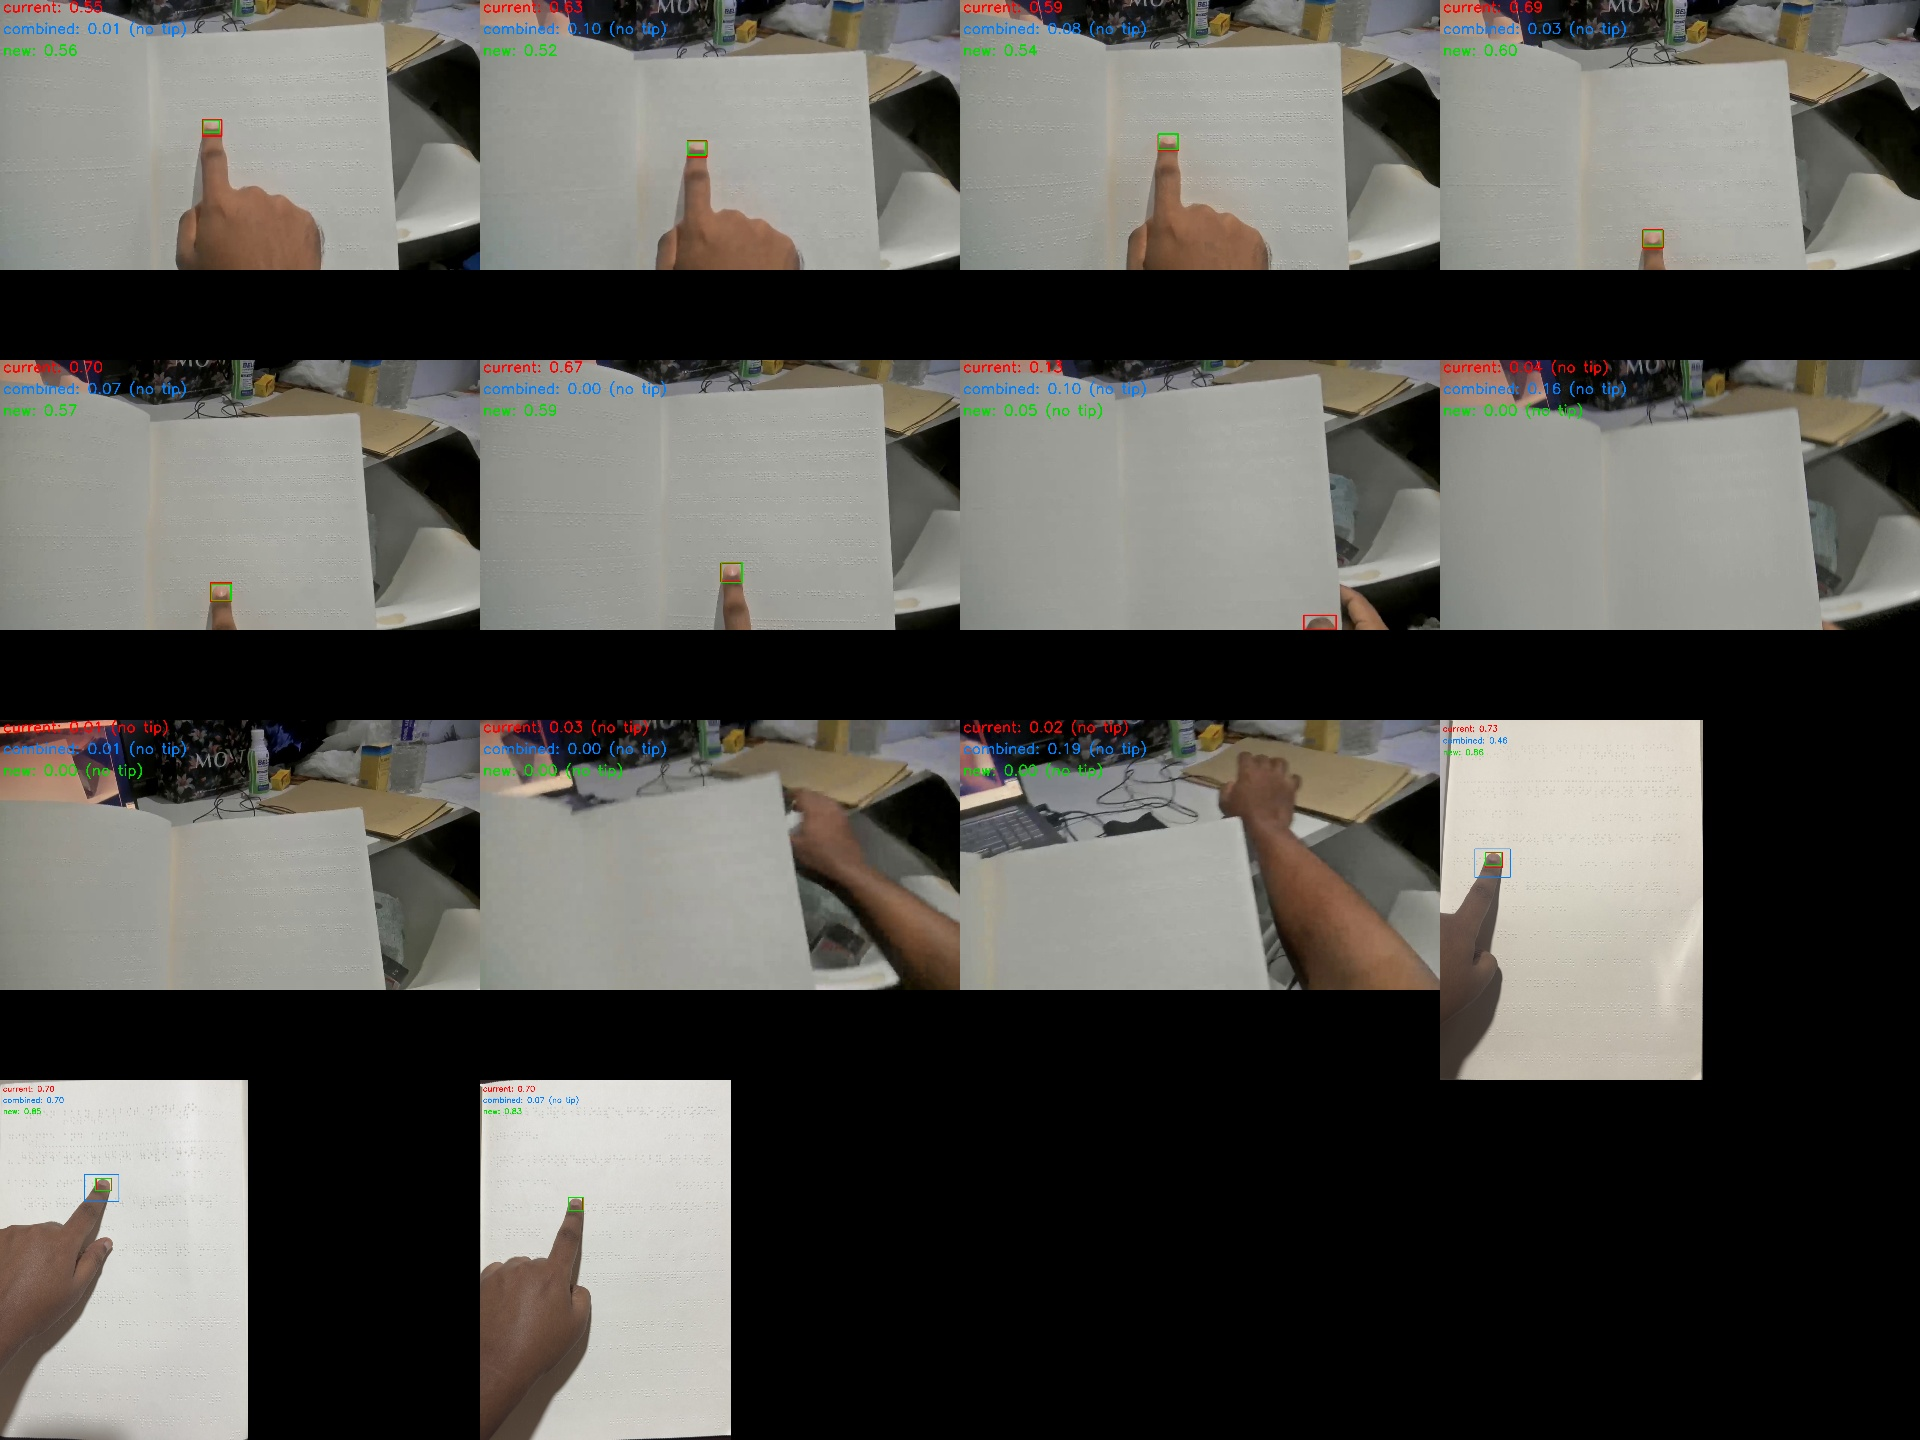

red = current app model | blue = combined (3 Oct) | green = new; '(no tip)' = below that model's threshold


In [13]:
vis_imgs = [im for im, _ in gl_eval[::22]] + [cv2.imread(str(p)) for p in imgs(B / "glasses" / "ambiguous" / "images")[::6]] + [im for _, im, _ in BR["test"][:3]]
colors = {"current": (0, 0, 255), "combined": (255, 128, 0), "new": (0, 220, 0)}
tiles = []
for im in vis_imgs:
    vis = im.copy(); t = max(2, im.shape[1] // 400); y = 40
    for name, m in MODELS.items():
        b, s = best_boxes(m, [im])[0]
        ok = s >= THR[name]
        if ok:
            cv2.rectangle(vis, tuple(map(int, b[:2])), tuple(map(int, b[2:])), colors[name], t)
        cv2.putText(vis, f"{name}: {s:.2f}" + ("" if ok else " (no tip)"), (10, y), cv2.FONT_HERSHEY_SIMPLEX, im.shape[1] / 1000, colors[name], t)
        y += int(im.shape[1] / 22)
    sc = min(480 / vis.shape[1], 360 / vis.shape[0]); vis = cv2.resize(vis, (int(vis.shape[1] * sc), int(vis.shape[0] * sc)))
    canvas = np.zeros((360, 480, 3), np.uint8); canvas[:vis.shape[0], :vis.shape[1]] = vis; tiles.append(canvas)
tiles += [np.zeros_like(tiles[0])] * (-len(tiles) % 4)
cv2.imwrite(str(OUT / "fingertip_visual_check.jpg"), np.vstack([np.hstack(tiles[i:i + 4]) for i in range(0, len(tiles), 4)]))
display(_Img(str(OUT / "fingertip_visual_check.jpg"), width=1400))
print("red = current app model | blue = combined (3 Oct) | green = new; '(no tip)' = below that model's threshold")

## 9) Export for the app + app-faithful check of the exported file
Same flags as `finger_cell_track/yolo_domain_specific/export_to_onnx.py`: 640×640, opset 12, `nms=False` (YOLO26's
end-to-end head already outputs `[1, 300, 6]` rows, which is what `FingertipOnnxService` parses), UINT8 mobile copy.

In [14]:
import onnx, onnxruntime as ort
from onnxruntime.quantization import QuantType, quantize_dynamic
EXP = OUT / "export"; EXP.mkdir(exist_ok=True)
onnx_path = Path(YOLO(str(NEW_PT)).export(format="onnx", imgsz=IMGSZ, simplify=True, opset=12, dynamic=False,
                                          half=False, nms=False, batch=1, device="cpu"))
fp32 = EXP / "fingertip_robust_yolo26n.onnx"; shutil.copy2(onnx_path, fp32)
m = onnx.load(str(fp32))
if m.ir_version > 9:
    m.ir_version = 9; onnx.save_model(m, str(fp32))
out_shape = [d.dim_value for d in m.graph.output[0].type.tensor_type.shape.dim]
assert out_shape[-1] == 6, f"output {out_shape}: the app expects end-to-end rows [1, N, 6]"
mobile = EXP / "fingertip_robust_yolo26n_mobile.onnx"
quantize_dynamic(str(fp32), str(mobile), weight_type=QuantType.QUInt8)

def onnx_best(sess, bgr):
    """FingertipOnnxService: letterbox 640 (pad 114), RGB/255, best row with class 0."""
    h, w = bgr.shape[:2]; sc = min(640 / w, 640 / h); nw, nh = round(w * sc), round(h * sc)
    px, py = round((640 - nw) / 2), round((640 - nh) / 2)
    canvas = np.full((640, 640, 3), 114, np.uint8)
    canvas[py:py + nh, px:px + nw] = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), (nw, nh), interpolation=cv2.INTER_NEAREST)
    o = sess.run(None, {"images": canvas.transpose(2, 0, 1)[None].astype(np.float32) / 255})[0][0]
    o = o[o[:, 5].round() == 0]
    if not len(o):
        return None, 0.0
    r = o[o[:, 4].argmax()]
    return np.array([(r[0] - px) / sc, (r[1] - py) / sc, (r[2] - px) / sc, (r[3] - py) / sc]), float(r[4])

sess = ort.InferenceSession(str(mobile), providers=["CPUExecutionProvider"])
onnx_rows = []
for k in ("Braille test photos", "glasses video, finger present (held-out segment)", "glasses video, no hand (held-out segment)",
          "Gold Braille pages, no hand (+lighting)", "tip-free crops of Braille test photos", "Braille test + dark (sev 2)"):
    preds = [onnx_best(sess, im) for im, _ in TEST[k]]
    onnx_rows.append({"set": k, **metrics(preds, TEST[k], THR["new"])})
onnx_table = pd.DataFrame(onnx_rows).set_index("set"); display(onnx_table)
onnx_table.to_csv(OUT / "fingertip_onnx_mobile_check.csv")

(EXP / "fingertip_robust_yolo26n_meta.json").write_text(json.dumps({
    "model": fp32.name, "task": "detect", "class_names": ["fingertip"], "num_classes": 1, "imgsz": IMGSZ,
    "input_layout": "NCHW", "color_format": "RGB", "normalize": {"scale": 1 / 255, "mean": [0, 0, 0], "std": [1, 1, 1]},
    "conf_threshold": THR["new"], "iou_threshold": 0.45, "nms_in_app": False,
    "output_format": f"Each row: [x1, y1, x2, y2, confidence, class_id] in 640x640 letterbox coords. Max {out_shape[1]} candidates.",
    "inputs": [{"name": "images", "shape": [1, 3, IMGSZ, IMGSZ], "dtype": "float32"}],
    "outputs": [{"name": "output0", "shape": out_shape}],
    "source_weights": NEW_PT.name,
    "provenance_notes": ("Fine-tuned from yolo26n.pt on public TI1K+Roboflow fingertips plus oversampled Braille fingertip "
                         "photos and pseudo-labelled glasses-camera frames, with lighting augmentation and no-fingertip "
                         "negatives (Gold Braille pages, glasses frames without a hand, tip-free crops, COCO without people). "
                         "conf_threshold chosen on validation data including negatives."),
    "flutter_notes": (f"Preprocess: letterbox resize to 640x640, RGB, float32, divide by 255. Parse output0: filter "
                      f"confidence >= {THR['new']} and class_id == 0, take highest-confidence row; none -> no fingertip."),
}, indent=2))

summary = {"thresholds_val": THR, "tracking": track.reset_index().to_dict(orient="records"),
           "onnx_mobile_check": onnx_table.reset_index().to_dict(orient="records"),
           "comparison": res.to_dict(orient="records"), "train_sources": stats, "bundle": BMETA}
(OUT / "fingertip_robust_summary.json").write_text(json.dumps(summary, indent=2, default=str))
for p in sorted(EXP.iterdir()):
    print(f"{p.name:42s} {p.stat().st_size / 1e6:6.2f} MB")
print("\nAll results in", OUT)

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/BrailleLens_Fingertip_Domain/fingertip_robust_outputs/yolo26n_fingertip_robust_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.23.1 opset 12...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 2.3s, saved as '/content/drive/MyDrive/BrailleLens_Fingertip_Domain/fingertip_robust_outputs/yolo26n_fingertip_robust_best.onnx' (9.4 MB)

Export complete (2.7s)
Results saved to /content/drive/MyDrive/BrailleLens_Fingertip_Domain/fingertip_robust_outputs/yolo26n_fing

,n_pos,found,hit,iou50,err_pct,n_neg,false_tip
set,,,,,,,
Braille test photos,6.0,1.000,1.000,1.000,0.121,NaN,NaN
"glasses video, finger present (held-out segment)",131.0,0.893,0.934,0.934,0.173,NaN,NaN
"glasses video, no hand (held-out segment)",NaN,NaN,NaN,NaN,NaN,68.0,0.00
"Gold Braille pages, no hand (+lighting)",NaN,NaN,NaN,NaN,NaN,20.0,0.25
tip-free crops of Braille test photos,NaN,NaN,NaN,NaN,NaN,30.0,0.00
Braille test + dark (sev 2),6.0,1.000,1.000,1.000,0.141,NaN,NaN


fingertip_robust_yolo26n.onnx                9.80 MB
fingertip_robust_yolo26n_meta.json           0.00 MB
fingertip_robust_yolo26n_mobile.onnx         2.87 MB

All results in /content/drive/MyDrive/BrailleLens_Fingertip_Domain/fingertip_robust_outputs


## 10) Bringing results back (only if better)
Download `fingertip_robust_outputs/`. Switch **only if** the new model beats the current one on the Braille test photos
(incl. the lighting rows) **and** the held-out glasses segment (found + tracking), with a lower false-tip rate.

| File | Goes to | App change |
|---|---|---|
| `yolo26n_fingertip_robust_best.pt` | `finger_cell_track/weights/` | — (source checkpoint) |
| `export/fingertip_robust_yolo26n_mobile.onnx` + `fingertip_robust_yolo26n.onnx` + `_meta.json` | `braille_lens_flutter/assets/models/` | point `fingertipOnnxAsset` / `fingertipOnnxFallbackAsset` (in `app_config.dart`) at them |
| `conf_threshold` in the meta file | — | `FingertipOnnxService` has `const confThresh = 0.25`; set it to the meta value |
| `*.csv`, `fingertip_robust_summary.json`, `*.jpg` | `finger_cell_track/fingertip_robust/results/` | — |